# 01 - Data cleaning

1. **Duplicate keys** Every datapoint is identified by
   `(raw_file, scan_number)`. Some are duplicated some precursor charges are - 
   we drop every duplicated key from both tables.
2. **Remove precursor charge 1 and 6** They are
   extremely rare (57 and 6 rows) and only add noise / unstable classes - can we actually do this?
3. **Outer join data x meta** Some precursor charges are missing, lets predict them in notebook #2
4. **Validate**: `matched_ions` and `intensities_raw` must
   be of equal length, every ion must be a single-charge `b`/`y` ion.
5. **Normalize**: base-peak normalised intensities laid out
   in a fixed 58-dim vector (29 fragment numbers x {b, y}).

Output to `clean_spectra.parquet` for reuse.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common as c

pd.set_option("display.max_columns", 20)

### Load and merge

In [2]:
df_raw = pd.read_parquet("../data_for_student.parquet")
meta_raw = pd.read_parquet("../metadata_for_student.parquet")
print("data    :", df_raw.shape)
print("metadata:", meta_raw.shape)

data    : (355532, 5)
metadata: (350113, 3)


In [ ]:
# Inspect the duplicate-key problem before cleaning.
dup_meta = meta_raw[meta_raw.duplicated(["raw_file", "scan_number"], keep=False)]
print("duplicated metadata keys:", meta_raw.duplicated(["raw_file", "scan_number"]).sum())
print("duplicated data keys    :", df_raw.duplicated(["raw_file", "scan_number"]).sum())

dup_meta.sort_values(["raw_file", "scan_number"]).head(6)

duplicated metadata keys: 47
duplicated data keys    : 110

example of conflicting duplicate charges:


,raw_file,scan_number,precursor_charge
520966,01625b_GA4-TUM_first_pool_25_01_01-2xIT_2xHCD-...,27144,2
520967,01625b_GA4-TUM_first_pool_25_01_01-2xIT_2xHCD-...,27144,3
596251,01625b_GB5-TUM_first_pool_34_01_01-2xIT_2xHCD-...,26231,2
596252,01625b_GB5-TUM_first_pool_34_01_01-2xIT_2xHCD-...,26231,4
372009,01625b_GC3-TUM_first_pool_19_01_01-2xIT_2xHCD-...,26410,2
372010,01625b_GC3-TUM_first_pool_19_01_01-2xIT_2xHCD-...,26410,3


### Apply cleaning via the shared helper

In [ ]:
# left join, remove 1 & 6, keep incomplete data
merged = c.load_clean_merged(
    data_path="../data_for_student.parquet",
    meta_path="../metadata_for_student.parquet",
)

merged["precursor_charge"].value_counts(dropna=False).sort_index()

clean rows: 355260

charge distribution (NaN = to be predicted in nb 02):
precursor_charge
2.0    213593
3.0    125112
4.0     10938
5.0       217
NaN      5400
Name: count, dtype: int64


In [ ]:
# Confirm charge 1 and 6 are gone.
assert not merged["precursor_charge"].isin([1, 6]).any()
n_missing = merged["precursor_charge"].isna().sum()
print(f"missing charge rows: {n_missing} ({n_missing / len(merged) * 100:.2f}%)")

missing charge rows kept: 5400 (1.52%)


## Validate array consistency

In [ ]:
len_mismatch = (
    merged["matched_ions"].map(len) != merged["intensities_raw"].map(len)
).sum()
print("rows with ion/intensity length mismatch:", len_mismatch)

# Every ion must be a single-charge b/y ion with a number in range
def ions_ok(ions, L):
    for ion in ions:
        if ion[0] not in ("b", "y"):
            return False
        n = int(ion[1:])
        if not (1 <= n <= L - 1):
            return False
    return True

sample = merged.sample(20000, random_state=0)
ok = [ions_ok(r.matched_ions, r.pep_len) for r in sample.itertuples()]
print("fraction of sampled rows with valid ions:", np.mean(ok))
assert len_mismatch == 0

rows with ion/intensity length mismatch: 0


fraction of sampled rows with valid ions: 0.7711


### dense, base-peak-normalised fragment vectors

Each spectrum becomes a fixed-length vector of 58 slots. Slot
`(number-1)*2 + {b:0, y:1}` holds the intensity of that fragment, scaled so the
strongest peak in the spectrum is 1.0. Unobserved fragments are 0.

In [7]:
intensity_vectors = np.stack([
    c.ions_to_vector(ions, ints, normalize=True)
    for ions, ints in zip(merged["matched_ions"], merged["intensities_raw"])
])
print("intensity matrix:", intensity_vectors.shape)
print("max per row is 1.0:", np.allclose(intensity_vectors.max(axis=1), 1.0))

intensity matrix: (355260, 58)
max per row is 1.0: True


In [ ]:
nnz = (intensity_vectors > 0).sum(axis=1)
print("mean observed fragments per spectrum:", nnz.mean().round(2))
print("median peptide length:", int(merged["pep_len"].median()))

mean observed fragments per spectrum: 19.84
median peptide length: 13


## A quick look at the cleaned data

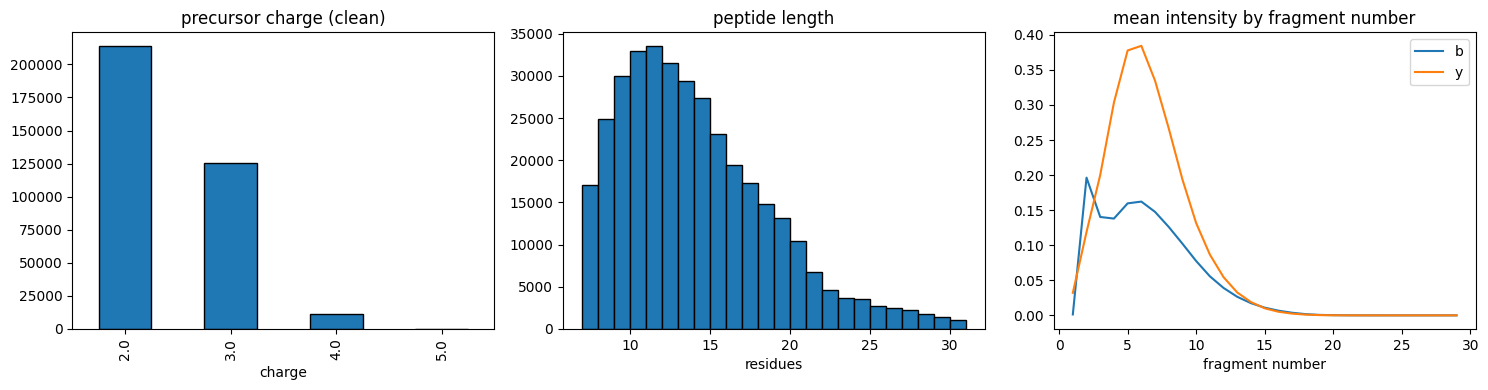

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

merged["precursor_charge"].value_counts().sort_index().plot.bar(
    ax=axes[0], edgecolor="black"
)
axes[0].set_title("precursor charge (clean)")
axes[0].set_xlabel("charge")

axes[1].hist(merged["pep_len"], bins=range(7, 32), edgecolor="black")
axes[1].set_title("peptide length")
axes[1].set_xlabel("residues")

# Mean fragment intensity by position (b vs y) reveals the expected ramp.
b_slots = [c.fragment_slot("b", n) for n in range(1, c.MAX_FRAGMENTS + 1)]
y_slots = [c.fragment_slot("y", n) for n in range(1, c.MAX_FRAGMENTS + 1)]
axes[2].plot(range(1, c.MAX_FRAGMENTS + 1), intensity_vectors[:, b_slots].mean(0), label="b")
axes[2].plot(range(1, c.MAX_FRAGMENTS + 1), intensity_vectors[:, y_slots].mean(0), label="y")
axes[2].set_title("mean intensity by fragment number")
axes[2].set_xlabel("fragment number")
axes[2].legend()

plt.tight_layout()
plt.show()

### Save to disk

In [ ]:
# Only store base data
# Downstream rebuilds dense vectors via common.ions_to_vector -> less storage
out = merged[[
    "raw_file", "scan_number", "peptide_sequence", "pep_len",
    "precursor_charge", "matched_ions", "intensities_raw",
]].copy()
out.to_parquet("clean_spectra.parquet", index=False)
print("wrote clean_spectra.parquet:", out.shape)
out.head(3)

wrote clean_spectra.parquet: (355260, 7)


,raw_file,scan_number,peptide_sequence,pep_len,precursor_charge,matched_ions,intensities_raw
0,01650b_BG4-TUM_first_pool_73_01_01-2xIT_2xHCD-...,48156,HLTVEELFGTSLPK,14,3.0,"[y1, y2, b2, b3, y3, y4, b4, y5, b5, y6, b6, y...","[116.713806152344, 54029.1484375, 1521.8664550..."
1,02208a_GC10-TUM_second_addon_34_01_01-2xIT_2xH...,5465,SM[UNIMOD:35]ASNHETAHNVIC[UNIMOD:4]K,15,4.0,"[y1, b2, b3, y2, b4, y3, b5, y4, y5, b6, y6, y...","[10120.6884765625, 133350.921875, 22052.142578..."
2,02080d_GB1-TUM_isoform_109_01_01-2xIT_2xHCD-1h-R1,29548,PHKC[UNIMOD:4]PDC[UNIMOD:4]DMAFVTSGELVR,19,4.0,"[y1, b2, y2, b3, y3, y4, b4, y5, b5, y6, b6, y...","[11643.265625, 12050.8876953125, 48106.8476562..."
